## 1) Préparation de l'environnement

Cette cellule installe les bibliothèques nécessaires à l'analyse financière en Python (`yfinance`, `statsmodels`).

L'objectif est d'avoir un environnement reproductible pour :
- récupérer les données de marché,
- faire des tests économétriques,
- estimer des modèles de risque/rendement.

In [2]:
!pip install yfinance
!pip install statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2) Imports et cadre d'analyse

Ici, on importe les modules pour manipuler les séries temporelles financières et produire les graphiques.

Notion clé : une série de prix boursiers est une **série temporelle**. On étudie son évolution dans le temps pour mesurer :
- la tendance,
- le risque (volatilité),
- et la relation avec le marché.

In [17]:
import yfinance as yf
import pandas as pd
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
import statsmodels.api as sm

## 3) Collecte des données de marché

Cette cellule télécharge les prix de clôture des GAFAM et de deux indices de référence (`S&P 500`, `Nasdaq`) depuis Yahoo Finance.

Notion finance : le **prix de clôture** est souvent utilisé comme référence quotidienne, car il résume la valorisation de l'actif en fin de séance.

In [10]:


# choisir une entreprise
tickers = ["AAPL", "AMZN", "META", "GOOGL", "MSFT","^GSPC","^IXIC"]

# télécharger les données
df = yf.download(tickers, start="2018-01-01")

# garder uniquement le prix de clôture
close = df["Close"]

# afficher les premières lignes
print(close)
print(close.columns)

[*********************100%***********************]  7 of 7 completed


Ticker            AAPL        AMZN       GOOGL        META        MSFT  \
Date                                                                     
2018-01-02   40.304173   59.450500   53.220631  180.007401   78.870369   
2018-01-03   40.297150   60.209999   54.128624  183.232101   79.237411   
2018-01-04   40.484329   60.479500   54.338890  182.894775   79.934822   
2018-01-05   40.945271   61.457001   55.059437  185.395111   80.925842   
2018-01-08   40.793175   62.343498   55.253830  186.813995   81.008423   
...                ...         ...         ...         ...         ...   
2026-04-10  260.480011  238.380005  317.239990  629.859985  370.869995   
2026-04-13  259.200012  239.889999  321.309998  634.530029  384.369995   
2026-04-14  258.829987  249.020004  332.910004  662.489990  393.109985   
2026-04-15  266.429993  248.500000  337.119995  671.580017  411.220001   
2026-04-16  263.399994  249.699997  336.019989  676.869995  420.260010   

Ticker            ^GSPC         ^IXIC

## 4) Visualisation des prix bruts

On renomme les tickers pour une lecture plus claire puis on trace les prix de clôture.

Attention à l'interprétation : comparer des **prix bruts** est utile visuellement, mais cela peut être trompeur car chaque actif a une échelle de prix différente.

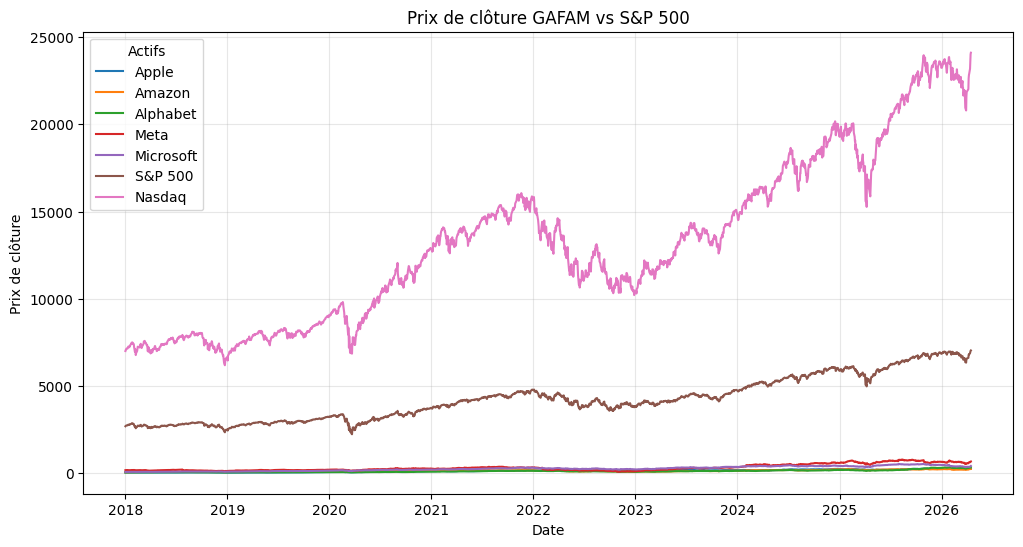

In [11]:
close = close.rename(columns={
    "AAPL": "Apple",
    "AMZN": "Amazon",
    "META": "Meta",
    "GOOGL": "Alphabet",
    "MSFT": "Microsoft",
    "^GSPC": "S&P 500",
    "^IXIC": "Nasdaq"
})

# Plot
plt.figure(figsize=(12,6))

for col in close.columns:
    plt.plot(close.index, close[col], label=col)

plt.title("Prix de clôture GAFAM vs S&P 500")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.legend(title="Actifs")
plt.grid(True, alpha=0.3)
plt.show()

## 5) Normalisation en base 100

Cette cellule transforme chaque série de prix en **base 100** à la date initiale.

Notion finance : la base 100 permet de comparer les performances relatives de plusieurs actifs, indépendamment de leur niveau de prix initial.

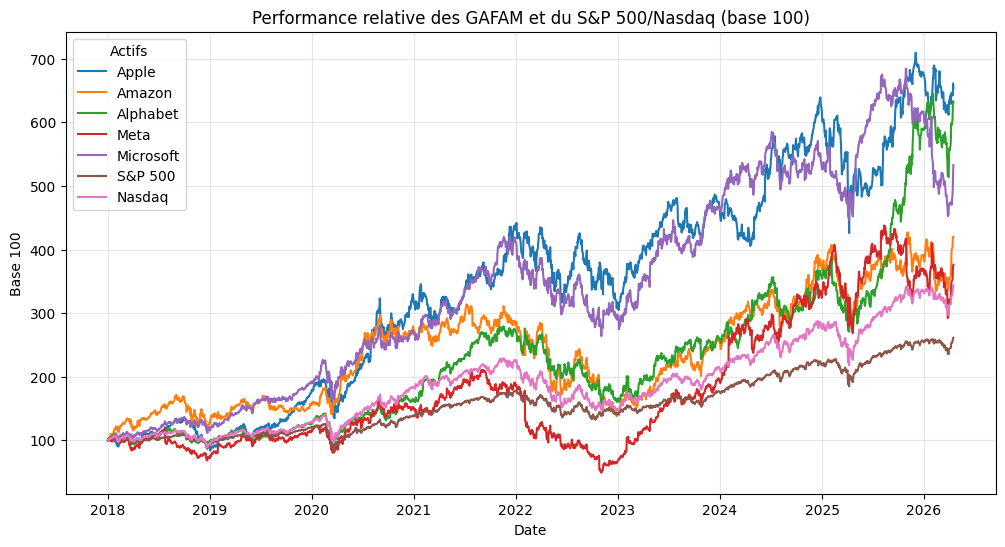

In [13]:
# Base 100
close_base100 = close / close.iloc[0] * 100

# Plot
plt.figure(figsize=(12,6))

for col in close_base100.columns:
    plt.plot(close_base100.index, close_base100[col], label=col)

plt.title("Performance relative des GAFAM et du S&P 500/Nasdaq (base 100)")
plt.xlabel("Date")
plt.ylabel("Base 100")
plt.legend(title="Actifs")
plt.grid(True, alpha=0.3)

plt.show()

## 6) Test de stationnarité (ADF) sur les prix

On applique le test Augmented Dickey-Fuller (ADF) sur chaque série de prix.

Notion économétrique :
- **H0** : la série a une racine unitaire (non stationnaire),
- **H1** : la série est stationnaire.

En finance, les prix sont souvent non stationnaires, ce qui motive l'utilisation des rendements pour la modélisation.

In [14]:


for col in close.columns:
    result = adfuller(close[col].dropna())
    print(f"{col}")
    print("ADF statistic:", result[0])
    print("p-value:", result[1])
    print("-" * 30)

#On ne rejette pas H0
#La série des prix de l’action est non stationnaire.

Apple
ADF statistic: -0.5606177080873505
p-value: 0.8796348488491469
------------------------------
Amazon
ADF statistic: -1.147306777228042
p-value: 0.6958427827355944
------------------------------
Alphabet
ADF statistic: 1.8600599112976026
p-value: 0.9984609836518346
------------------------------
Meta
ADF statistic: -0.2930333718923663
p-value: 0.9264852362293059
------------------------------
Microsoft
ADF statistic: -1.069337670149798
p-value: 0.7271435506336937
------------------------------
S&P 500
ADF statistic: 0.3483743383463334
p-value: 0.9794582124045973
------------------------------
Nasdaq
ADF statistic: 0.24546472241745432
p-value: 0.9746993427375816
------------------------------


## 7) Passage aux rendements logarithmiques

Cette cellule calcule les **rendements logarithmiques** (log-returns) :

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Si la formule s'affiche mal dans Jupyter, utilise toujours des blocs `$$ ... $$` sur des lignes séparées (comme ci-dessus), puis ré-exécute la cellule markdown.

Pourquoi c'est important :
- les rendements sont en général plus proches de la stationnarité que les prix,
- ils sont additifs dans le temps,
- ils permettent de comparer plus proprement le risque entre actifs.

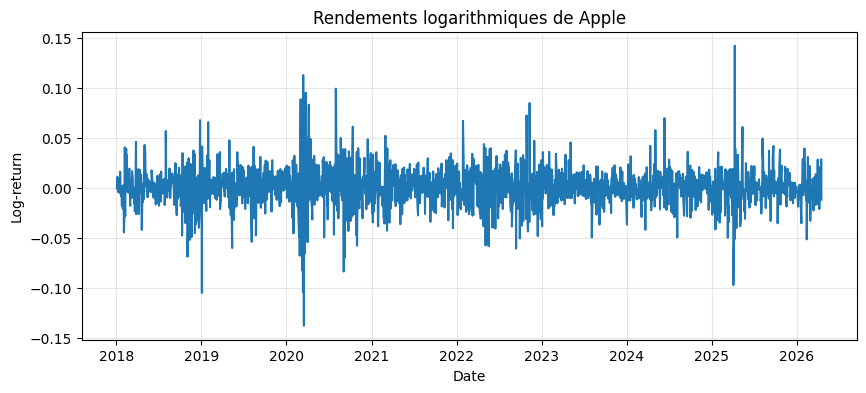

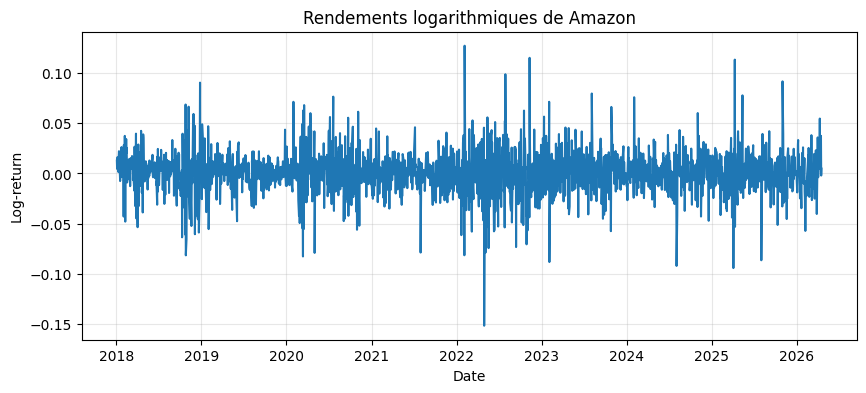

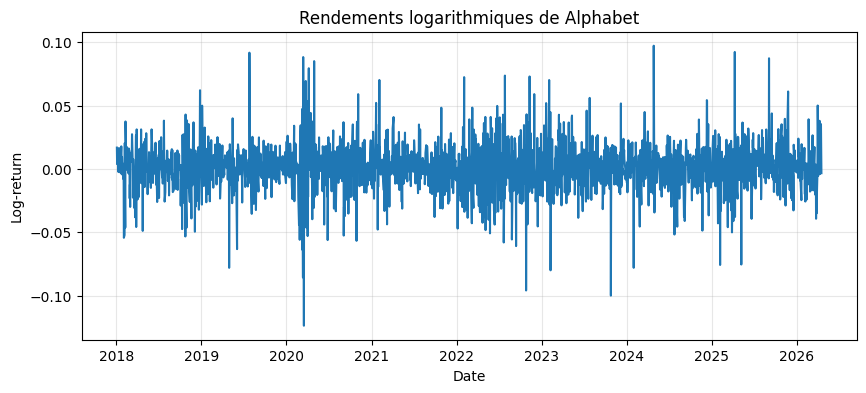

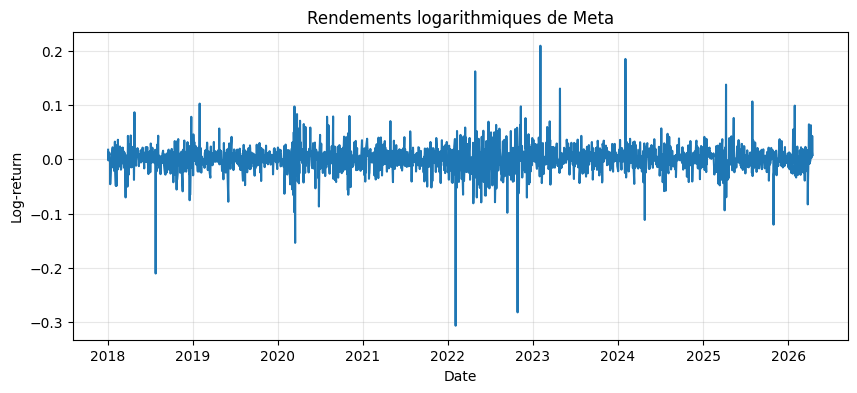

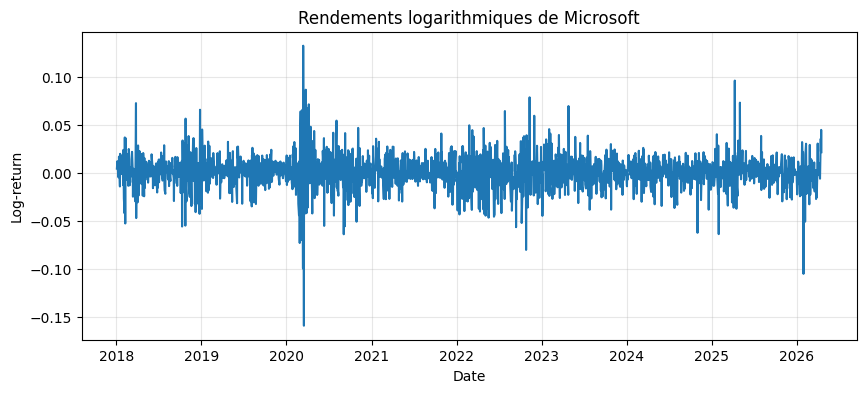

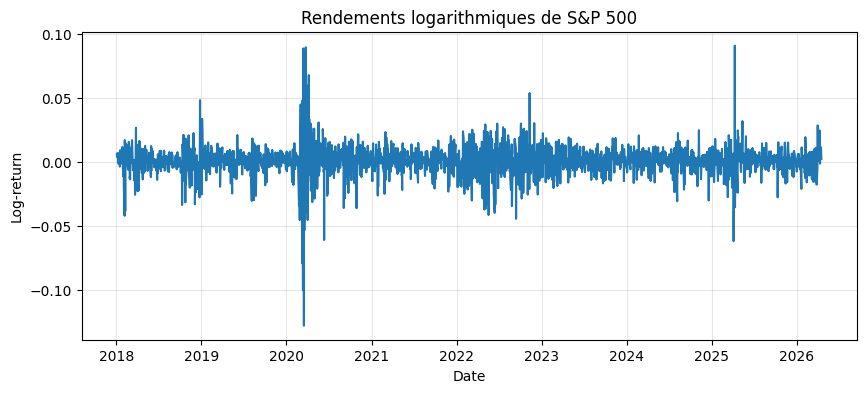

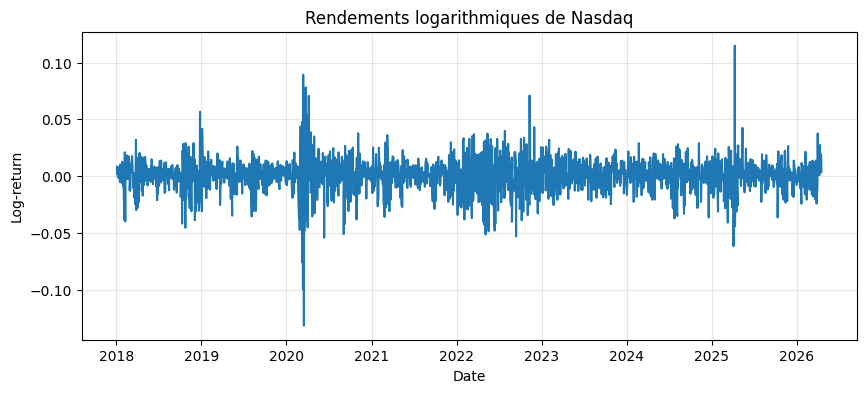

In [15]:

# Rendements logarithmiques
returns = np.log(close / close.shift(1)).dropna()

# Un graphique par actif
for col in returns.columns:
    plt.figure(figsize=(10,4))
    plt.plot(returns.index, returns[col])
    plt.title(f"Rendements logarithmiques de {col}")
    plt.xlabel("Date")
    plt.ylabel("Log-return")
    plt.grid(True, alpha=0.3)
    plt.show()

## 9) CAPM : alpha, beta et rendements excedentaires

On construit ici une estimation CAPM pour chaque action :
1. recuperation du taux sans risque (`^IRX`),
2. calcul des rendements excedentaires (actif - sans risque),
3. regression OLS contre deux marches de reference (`S&P 500` et `Nasdaq`).

Formules du modele CAPM (version empirique) :

$$
R_i - R_f = \alpha_i + \beta_i (R_m - R_f) + \varepsilon_i
$$

$$
\beta_i = \frac{\mathrm{Cov}(R_i - R_f,\; R_m - R_f)}{\mathrm{Var}(R_m - R_f)}
$$

$$
\alpha_i = \mathbb{E}[R_i - R_f] - \beta_i\,\mathbb{E}[R_m - R_f]
$$

Interpretation financiere :
- **beta** mesure la sensibilite de l'actif au marche (risque systematique),
- **alpha** mesure la performance anormale (sur/sous-performance apres ajustement du risque de marche),
- **R²** indique la part de variance expliquee par le facteur marche.

In [18]:
# 5. Taux sans risque (^IRX)
rf_raw = yf.download("^IRX", start="2018-01-01", auto_adjust=True)["Close"]

# Si yf renvoie un DataFrame à une colonne, on le transforme en Series
if isinstance(rf_raw, pd.DataFrame):
    rf_raw = rf_raw.squeeze()

# Réindexation sur les dates des rendements
rf_raw = rf_raw.reindex(returns.index).ffill()

# Conversion en taux journalier décimal
rf_daily = (rf_raw / 100) / 252

# 6. Rendements excédentaires
excess_returns = returns.sub(rf_daily, axis=0).dropna()

# Vérification utile
print("Colonnes excess_returns :", excess_returns.columns)
print("Nombre de lignes :", len(excess_returns))

# 7. Marchés
market_sp = excess_returns["S&P 500"]
market_nasdaq = excess_returns["Nasdaq"]

# 8. Régressions
rows = []

for col in excess_returns.columns:
    if col not in ["S&P 500", "Nasdaq"]:
        
        # ------- Régression contre S&P 500 -------
        tmp_sp = pd.concat([excess_returns[col], market_sp], axis=1).dropna()
        tmp_sp.columns = ["y", "market"]
        
        X_sp = sm.add_constant(tmp_sp["market"])
        model_sp = sm.OLS(tmp_sp["y"], X_sp).fit()

        # ------- Régression contre Nasdaq -------
        tmp_nq = pd.concat([excess_returns[col], market_nasdaq], axis=1).dropna()
        tmp_nq.columns = ["y", "market"]
        
        X_nq = sm.add_constant(tmp_nq["market"])
        model_nq = sm.OLS(tmp_nq["y"], X_nq).fit()

        rows.append({
            "asset": col,
            "alpha_sp": model_sp.params["const"],
            "beta_sp": model_sp.params["market"],
            "R2_sp": model_sp.rsquared,
            "alpha_nasdaq": model_nq.params["const"],
            "beta_nasdaq": model_nq.params["market"],
            "R2_nasdaq": model_nq.rsquared
        })

df_capm = pd.DataFrame(rows).set_index("asset")
print(df_capm.round(6))

[*********************100%***********************]  1 of 1 completed

Colonnes excess_returns : Index(['Apple', 'Amazon', 'Alphabet', 'Meta', 'Microsoft', 'S&P 500',
       'Nasdaq'],
      dtype='object', name='Ticker')
Nombre de lignes : 2082
           alpha_sp   beta_sp     R2_sp  alpha_nasdaq  beta_nasdaq  R2_nasdaq
asset                                                                        
Apple      0.000366  1.206581  0.592517      0.000289     1.039159   0.646852
Amazon     0.000164  1.179621  0.448691      0.000039     1.116337   0.591434
Alphabet   0.000368  1.154923  0.532676      0.000282     1.019997   0.611515
Meta       0.000057  1.327895  0.382758     -0.000065     1.220073   0.475577
Microsoft  0.000281  1.171029  0.639599      0.000202     1.017713   0.711010
